In [1]:
import math
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pyproj import Transformer, CRS
from scipy.spatial import cKDTree

url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/ice_sheet_temperature/SM_TEST_MIR_ITUDP4_20130101T000000_20141231T000000_200_001_0.zarr/'


target_crs = "EPSG:3031"
target_resolution = 25_000  # metres

depths_to_plot = [0, 500, 1000, 1500, 2000, 3000]

plot_celsius = True

In [2]:
ds = xr.open_zarr(url)
ds

<xarray.Dataset> Size: 17MB
Dimensions:      (x: 200, y: 224, depth: 91)
Coordinates:
  * depth        (depth) int16 182B 0 50 100 150 200 ... 4350 4400 4450 4500
Dimensions without coordinates: x, y
Data variables:
    latitude     (x, y) float64 358kB dask.array<chunksize=(200, 224), meta=np.ndarray>
    longitude    (x, y) float64 358kB dask.array<chunksize=(200, 224), meta=np.ndarray>
    QualityFlag  (x, y) float32 179kB dask.array<chunksize=(200, 224), meta=np.ndarray>
    spatial_ref  int64 8B ...
    Tice         (x, y, depth) float32 16MB dask.array<chunksize=(200, 224, 15), meta=np.ndarray>
Attributes: (12/21)
    product:               Internal ice sheet temperature
    product_version:       2.0
    institution:           IFAC-CNR, IGE
    description:           developed from SMOS L3 (CATDS)
    source:                IFAC L4Tice processor
    project:               ESA CryoSMOS project (contract n.4000112262/14/I-NB)
    ...                    ...
    geospatial_lat_max:    0
    geospatial_lon_min:    -180
    geospatial_lon_max:    180
    spatial_resolution:    25 km
    srid:                  EPSG:6932
    creation_date:         2019-09-20T15:14:23

In [3]:
available_depths = ds["depth"].values

depth_indices = [
    int(np.argmin(np.abs(available_depths - depth)))
    for depth in depths_to_plot
]

# Remove duplicate indices while keeping order
depth_indices = list(dict.fromkeys(depth_indices))

selected_depths = available_depths[depth_indices]

print("Selected depths:", selected_depths)

Selected depths: [   0  500 1000 1500 2000 3000]


In [ ]:
# reproject grid points to target grid

lat = ds["latitude"].values
lon = ds["longitude"].values

# Normalize longitude to [-180, 180]
lon = ((lon + 180) % 360) - 180

transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)

source_x, source_y = transformer.transform(lon, lat)

geo_mask = (
    np.isfinite(source_x)
    & np.isfinite(source_y)
    & np.isfinite(lat)
    & np.isfinite(lon)
)

source_points = np.column_stack([
    source_x[geo_mask],
    source_y[geo_mask],
])

print("Valid source points:", source_points.shape[0])

Valid source points: 44800


In [5]:
# create target grid
xmin = np.floor(np.nanmin(source_x) / target_resolution) * target_resolution
xmax = np.ceil(np.nanmax(source_x) / target_resolution) * target_resolution

ymin = np.floor(np.nanmin(source_y) / target_resolution) * target_resolution
ymax = np.ceil(np.nanmax(source_y) / target_resolution) * target_resolution

x_grid = np.arange(xmin, xmax + target_resolution, target_resolution)
y_grid = np.arange(ymin, ymax + target_resolution, target_resolution)

target_xx, target_yy = np.meshgrid(x_grid, y_grid)

target_points = np.column_stack([
    target_xx.ravel(),
    target_yy.ravel(),
])

print("Target grid shape:", target_xx.shape)

Target grid shape: (205, 229)


In [6]:
# warp existing points to target grid
tree = cKDTree(source_points)

distances, nearest_source_indices = tree.query(target_points, k=1)

nearest_source_indices = nearest_source_indices.reshape(target_xx.shape)

In [7]:
out_data = np.empty(
    shape=(len(depth_indices), len(y_grid), len(x_grid)),
    dtype=np.float32,
)

for i, depth_index in enumerate(depth_indices):
    depth_value = ds["depth"].values[depth_index]
    print(f"Reprojecting depth {depth_value} m")

    source_values = ds["Tice"].isel(depth=depth_index).values

    # Keep the same source pixels used in the KDTree.
    source_values_1d = source_values[geo_mask]

    # Nearest-neighbour assignment.
    # NaNs in source_values_1d are copied directly into the output.
    out_data[i, :, :] = source_values_1d[nearest_source_indices]

Reprojecting depth 0 m
Reprojecting depth 500 m
Reprojecting depth 1000 m
Reprojecting depth 1500 m
Reprojecting depth 2000 m
Reprojecting depth 3000 m


In [9]:
# generate dataset with resutls
crs3031 = CRS.from_epsg(3031)

tice_3031 = xr.Dataset(
    data_vars={
        "Tice": (
            ("depth", "y", "x"),
            out_data,
            {
                "long_name": "Ice sheet temperature",
                "units": ds["Tice"].attrs.get("units", "K"),
                "grid_mapping": "spatial_ref",
                "reprojection_method": "nearest",
            },
        ),
        "spatial_ref": (
            (),
            0,
            {
                "spatial_ref": crs3031.to_wkt(),
                "crs_wkt": crs3031.to_wkt(),
                "epsg_code": "EPSG:3031",
            },
        ),
    },
    coords={
        "depth": selected_depths,
        "x": (
            "x",
            x_grid,
            {
                "standard_name": "projection_x_coordinate",
                "units": "m",
            },
        ),
        "y": (
            "y",
            y_grid,
            {
                "standard_name": "projection_y_coordinate",
                "units": "m",
            },
        ),
    },
    attrs={
        **ds.attrs,
        "target_crs": "EPSG:3031",
        "target_resolution_m": target_resolution,
        "reprojection_note": "Nearest-neighbour reprojection. Source NaNs are preserved.",
    },
)

tice_3031

<xarray.Dataset> Size: 1MB
Dimensions:      (depth: 6, y: 205, x: 229)
Coordinates:
  * depth        (depth) int16 12B 0 500 1000 1500 2000 3000
  * x            (x) float64 2kB -2.85e+06 -2.825e+06 ... 2.825e+06 2.85e+06
  * y            (y) float64 2kB -2.55e+06 -2.525e+06 ... 2.525e+06 2.55e+06
Data variables:
    Tice         (depth, y, x) float32 1MB nan nan nan nan ... nan nan nan nan
    spatial_ref  int64 8B 0
Attributes: (12/24)
    product:               Internal ice sheet temperature
    product_version:       2.0
    institution:           IFAC-CNR, IGE
    description:           developed from SMOS L3 (CATDS)
    source:                IFAC L4Tice processor
    project:               ESA CryoSMOS project (contract n.4000112262/14/I-NB)
    ...                    ...
    spatial_resolution:    25 km
    srid:                  EPSG:6932
    creation_date:         2019-09-20T15:14:23
    target_crs:            EPSG:3031
    target_resolution_m:   25000
    reprojection_note:     Nearest-neighbour reprojection. Source NaNs are pr...

In [10]:
# use calving fronts as antarctica background
import geopandas as gpd
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/calving_fronts/Antarctic_coastlines.parquet'


gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)

gdf['area'] = gdf.area
largest_polygon = gdf.sort_values('area', ascending=False).iloc[[0]]

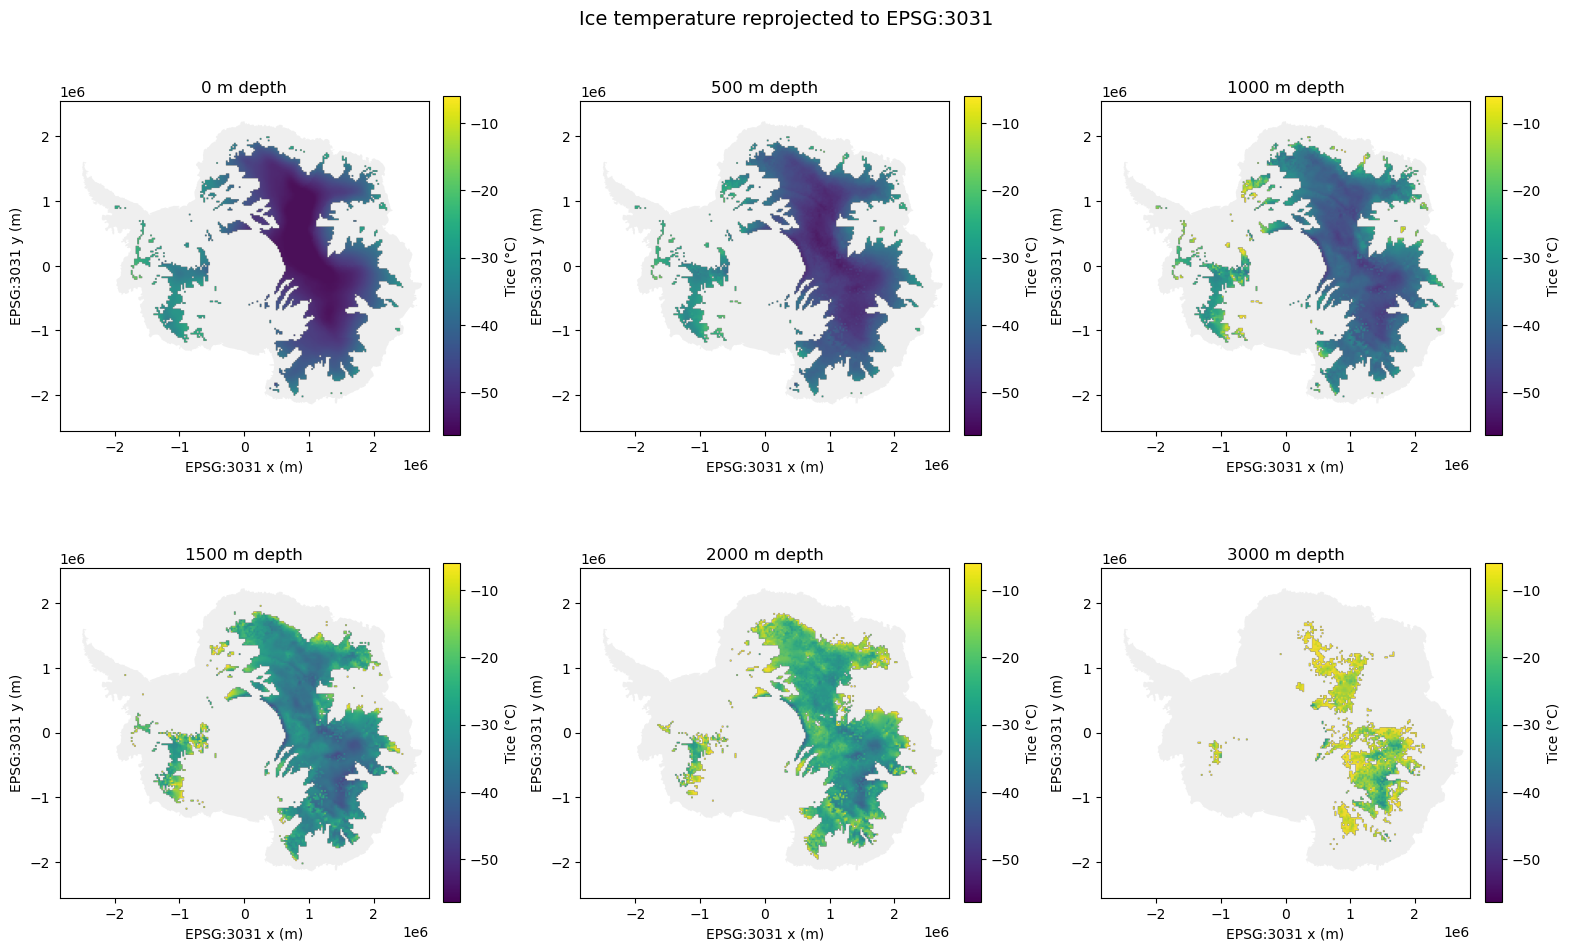

In [ ]:
# plot data
data = tice_3031["Tice"].values.copy()

if plot_celsius:
    data = data - 273.15
    units = "°C"
else:
    units = tice_3031["Tice"].attrs["units"]

vmin, vmax = np.nanpercentile(data, [2, 98])

nplots = len(selected_depths)
ncols = 3
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.2 * ncols, 4.8 * nrows),
    constrained_layout=True,
)

axes = np.atleast_1d(axes).ravel()

for i, depth in enumerate(selected_depths):
    
    ax = axes[i]

    largest_polygon.plot(ax=ax, color='grey', alpha=.12)

    im = ax.imshow(
        data[i, :, :],
        origin="lower",
        extent=[
            x_grid[0],
            x_grid[-1],
            y_grid[0],
            y_grid[-1],
        ],
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"{depth:g} m depth")
    ax.set_xlabel("EPSG:3031 x (m)")
    ax.set_ylabel("EPSG:3031 y (m)")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f"Tice ({units})")

for ax in axes[nplots:]:
    ax.set_visible(False)

fig.suptitle("Ice temperature reprojected to EPSG:3031", fontsize=14)

plt.show()